In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install pytorch-lightning


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 48.8 MB/s eta 0:00:00


In [ ]:
!pip install contractions

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 11.9 MB/s eta 0:00:00


In [ ]:
import os
import csv
import random
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
from typing import Dict, Any
from transformers import AutoTokenizer, AutoModel
import pytorch_lightning as pl
from pytorch_lightning.loggers import TensorBoardLogger
from pytorch_lightning.callbacks import EarlyStopping, ModelCheckpoint
from transformers import get_cosine_schedule_with_warmup
from sklearn.feature_extraction.text import TfidfVectorizer,ENGLISH_STOP_WORDS
from collections import Counter,defaultdict
import time
import contractions
import re
import warnings
warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", message="emoji is not installed*")
import torch
torch.set_float32_matmul_precision("high")
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report
import pandas as pd
import shutil
import time
import torch.nn.functional as F
import random, numpy as np, torch
from sklearn.metrics import precision_score, recall_score, f1_score

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

def expand_and_clean(text: str) -> str:
    expanded_text = contractions.fix(text)
    expanded_text = re.sub(r"[^a-zA-Z\s]", " ", expanded_text)
    expanded_text = re.sub(r"\s+", " ", expanded_text).strip().lower()

    return expanded_text

class CSVDatasetCls(Dataset):
    def __init__(self, csv_path, tokenizer, max_length=128, text_field="text", label_field="label"):
        assert os.path.isfile(csv_path), f"File not found: {csv_path}"
        self.tokenizer = tokenizer
        self.max_length = int(max_length)
        self.samples = []

        with open(csv_path, "r", encoding="utf-8") as f:
            reader = csv.DictReader(f)
            for row in reader:
                text = (row.get(text_field) or "").strip()
                label = row.get(label_field)
                if text != "" and label is not None:
                    self.samples.append({"text": text, "label": int(label)})

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        item = self.samples[idx]
        enc = self.tokenizer(item["text"], truncation=True, padding="max_length",
                             max_length=self.max_length, return_tensors="pt")
        return {
            "input_ids": enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "labels": torch.tensor(item["label"], dtype=torch.long)
        }
def compute_label_weighted_tfidf(train_dataset, tfidf_vectorizer, top_k=200):
    texts = [expand_and_clean(item["text"]) for item in train_dataset.samples]
    labels = np.array([item["label"] for item in train_dataset.samples])

    X = tfidf_vectorizer.transform(texts)
    feature_names = tfidf_vectorizer.get_feature_names_out()

    keyword_scores = {}
    for i, word in enumerate(feature_names):
        score = X[labels==1, i].mean() - X[labels==0, i].mean()
        keyword_scores[word] = score

    # top_k
    top_keywords = sorted(keyword_scores.items(), key=lambda x: abs(x[1]), reverse=True)[:top_k]
    return top_keywords



class EBTClassifier(pl.LightningModule):
    def __init__(self, hparams: Dict[str, Any], tokenizer=None, tfidf_vectorizer=None):
        super().__init__()
        self.save_hyperparameters(hparams)
        self.tfidf_vectorizer = tfidf_vectorizer
        self.tokenizer = tokenizer
        self.pos_keyword_scores = {}
        self.hp = hparams
        self.num_labels = hparams.get("num_labels", 2)
        self.encoder_name = hparams.get("encoder_name", "roberta-base")
        self.train_loss_epoch = []
        self.val_loss_epoch = []
        self.train_acc_epoch = []
        self.val_acc_epoch = []
        self.tokenizer = AutoTokenizer.from_pretrained(self.encoder_name)
        self.test_preds = []
        self.test_labels = []
        self.test_attn = []
        self.test_input_ids = []
        self.saved_samples = {
            "depressed": None,
            "non_depressed": None
        }
        # Encoder
        self.encoder = AutoModel.from_pretrained(self.encoder_name)
        hid = self.encoder.config.hidden_size
        self.self_attn = nn.MultiheadAttention(
            embed_dim=hid,
            num_heads=8,
            batch_first=True
        )
        self.gate = nn.Linear(hid, hid)
        self.attn = nn.Linear(hid, 1)
        self.norm = nn.LayerNorm(hid)
        self.dropout = nn.Dropout(0.2)
        self.energy_mlp = nn.Sequential(
            nn.Linear(hid + self.num_labels, 512),
            nn.SiLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.SiLU(),
            nn.Linear(256, 1),
        )

        # Optimization hyperparams
        self.y_steps = int(hparams.get("mcmc_num_steps", 4))
        self.y_step_size = float(hparams.get("mcmc_step_size", 0.5))
        self.langevin_sigma = float(hparams.get("langevin_sigma", 0.01))
        self.y_learnable_step = bool(hparams.get("mcmc_step_size_learnable", False))
        if self.y_learnable_step:
            self._alpha_raw = nn.Parameter(torch.tensor(self.y_step_size, dtype=torch.float32))
        else:
            self.register_buffer("_alpha_buf", torch.tensor(self.y_step_size, dtype=torch.float32))
        self.use_replay = hparams.get("use_replay_buffer", False)
        if self.use_replay:
            self.replay_buffer = []
            self.replay_size = int(hparams.get("replay_size", 1000))

        self.system_mode = hparams.get("system_mode", "S2")  # "S1"=fast (1-step), "S2"=multi-step thinking
        self.classification_loss = nn.CrossEntropyLoss(label_smoothing=0.1)
        self._kw_set = None

        self.val_loader_for_eval = None
    def on_fit_start(self):
        import time, torch
        torch.cuda.synchronize()
        self.train_start_time = time.time()

    def on_fit_end(self):
        import time, torch
        torch.cuda.synchronize()

        total_time = time.time() - self.train_start_time

        print(f"Total training time: {total_time:.2f} sec")

        self.logger.experiment.add_scalar("total_training_time", total_time)
    def get_alpha(self):
        if getattr(self, "y_learnable_step", False):
            return torch.nn.functional.softplus(self._alpha_raw)
        return self._alpha_buf


    def encode_text(self, input_ids, attention_mask, return_attn=False):
        out = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        token_embeddings = out.last_hidden_state

        attn_tokens, attn_weights = self.self_attn(
            token_embeddings,
            token_embeddings,
            token_embeddings,
            key_padding_mask=~attention_mask.bool(),
            need_weights=True,
            average_attn_weights=False
        )
        attn_tokens = self.norm(attn_tokens + token_embeddings)

        gate = torch.sigmoid(self.gate(attn_tokens))
        gated_tokens = attn_tokens * gate

        # Attention pooling
        scores = self.attn(gated_tokens).squeeze(-1)
        scores = scores.masked_fill(attention_mask == 0, -1e9)

        weights = torch.softmax(scores, dim=1)

        context_embed = (weights.unsqueeze(-1) * gated_tokens).sum(dim=1)
        context_embed = self.dropout(context_embed)
        if return_attn:
            return context_embed, attn_weights
        return context_embed

    def tfidf_sentence_prior(self, input_ids):
        if not hasattr(self, "pos_keyword_scores"):
            return torch.zeros((input_ids.size(0), 1), device=input_ids.device)

        priors = []
        for i in range(input_ids.size(0)):
            tokens = self.tokenizer.convert_ids_to_tokens(input_ids[i])
            s = 0.0
            cnt = 0
            for tok in tokens:
                tok = tok.replace("Ġ", "").replace("##", "").lower()
                tok = re.sub(r"[^a-z0-9]", "", tok)
                if tok in self.pos_keyword_scores:
                    s += self.pos_keyword_scores[tok]
                    cnt += 1
            priors.append(s / max(cnt, 1))

        return torch.tensor(priors, device=input_ids.device).unsqueeze(1)


    def energy(self, context_embed, y_logits):
        # y_logits: (B, num_labels)
        combined = torch.cat([context_embed, y_logits], dim=-1)
        energy_val = self.energy_mlp(combined)  # (B, 1)
        return energy_val

    def optimize_y(self, context_embed, y_init=None, num_steps=None, tfidf_bias=None):
        B = context_embed.size(0)
        device = context_embed.device
        if num_steps is None:
            num_steps = self.y_steps
        if self.training:
            num_steps = int(max(1, num_steps + random.choice([-1, 0, 1])))

        if y_init is None:
            y = torch.randn((B, self.num_labels), device=device, dtype=torch.float32, requires_grad=True)
        else:
            y = y_init.clone().to(device).float().requires_grad_(True)

        create_graph_flag = bool(getattr(self, "y_learnable_step", False) and self.training)

        for step_idx in range(num_steps):
            # compute energy and gradient wrt y
            with torch.enable_grad():
                e = self.energy(context_embed, y)
                if tfidf_bias is not None:
                    e = e + self.hp.get("tfidf_energy_coef", 0.02) * tfidf_bias

                e_sum = e.sum()
                grad_y_tuple = torch.autograd.grad(
                    e_sum,
                    y,
                    create_graph=create_graph_flag,
                    retain_graph=create_graph_flag,
                    allow_unused=False
                )
            grad_y = grad_y_tuple[0] if isinstance(grad_y_tuple, tuple) else grad_y_tuple
            if grad_y is None:
                raise RuntimeError("optimize_y: grad_y is None")

            # normalize gradient
            grad_norm = grad_y.norm(dim=-1, keepdim=True).clamp_min(1e-6)
            grad_y = grad_y / (grad_norm + 1e-8)

            step = self.get_alpha()
            if hasattr(step, "device") and step.device != device:
                step = step.to(device)
            step = step.float()

            if self.training:
                rand_multiplier = torch.empty(1, device=device).uniform_(0.8, 1.2)
                step = step * rand_multiplier

            y = y - step * grad_y
            if self.training and getattr(self, "langevin_sigma", 0.0) > 0:
                y = y + self.langevin_sigma * torch.randn_like(y)

            y = y.requires_grad_(True)

        return y

    def save_keywords_to_csv(self,csv_path="/content/drive/MyDrive/EBT/keywords_depression.csv"):
        if not hasattr(self, "pos_keyword_list") or not hasattr(self, "pos_keyword_scores"):
            print("No pos keywords present on model. Nothing saved.")
            return

        words = list(self.pos_keyword_list)
        scores = [self.pos_keyword_scores.get(w, 0.0) for w in words]

        with open(csv_path, "w", newline="", encoding="utf-8") as f:
            writer = csv.writer(f)
            writer.writerow(["keyword", "score"])
            for w, s in zip(words, scores):
                writer.writerow([w, s])

        print(f"Saved {len(words)} used keywords → {csv_path}")


    def compute_metrics(self, batch):
        input_ids, attention_mask, labels = batch["input_ids"], batch["attention_mask"], batch["labels"]
        input_ids = input_ids.to(self.device)
        attention_mask = attention_mask.to(self.device)
        labels = labels.to(self.device).long()

        was_training = self.training
        if not was_training:
            self.encoder.eval()
            self.energy_mlp.eval()

        # Context encoding
        context_embed = self.encode_text(input_ids, attention_mask)
        if not self.training:
            context_embed = context_embed.detach()
        # Optimize y
        steps = 1 if self.system_mode == "S1" else self.y_steps

        # (1) first-pass y (no TF-IDF)
        y_init = self.optimize_y(context_embed, num_steps=steps)

        # (2) uncertainty estimation
        with torch.no_grad():
            probs = torch.softmax(y_init, dim=-1)[:, 1]
            uncertainty = 1.0 - torch.abs(probs - 0.5) * 2
            uncertainty = uncertainty.clamp(0.0, 1.0)

        # (3) TF-IDF sentence prior
        tfidf_bias = self.tfidf_sentence_prior(input_ids)
        tfidf_bias = tfidf_bias * uncertainty.unsqueeze(1)

        # (4) second-pass y with TF-IDF prior
        y_optimized = self.optimize_y(
            context_embed,
            y_init=y_init.detach(),
            num_steps=steps,
            tfidf_bias=tfidf_bias
        )


        # Compute classification loss
        loss = self.classification_loss(y_optimized, labels)

        # Energy regularization (keep gradient!)
        energy_val = self.energy(context_embed, y_optimized)
        energy_reg = (energy_val ** 2).mean()
        total_loss = loss + self.hp.get("energy_reg_coef", 0.01) * energy_reg

        with torch.no_grad():
            preds = y_optimized.argmax(dim=-1)
            acc = (preds == labels).float().mean()

        return total_loss, acc, loss.detach(), energy_reg.detach(), preds.detach(), labels.detach()

    def training_step(self, batch, batch_idx):
        total_loss, acc, ce_loss, energy_reg , preds, labels= self.compute_metrics(batch)

        preds_np = preds.cpu().numpy()
        labels_np = labels.cpu().numpy()

        precision = precision_score(labels_np, preds_np, average="macro", zero_division=0)
        recall = recall_score(labels_np, preds_np, average="macro", zero_division=0)
        f1 = f1_score(labels_np, preds_np, average="macro", zero_division=0)

        # log (step-level; Lightning will also aggregate if you set on_epoch=True)
        self.log("train_loss", total_loss, prog_bar=True, on_step=True, on_epoch=True)
        self.log("train_acc", acc, prog_bar=True, on_step=True, on_epoch=True)
        self.log("train_precision_macro", precision, prog_bar=False, on_step=True, on_epoch=True)
        self.log("train_recall_macro", recall, prog_bar=False, on_step=True, on_epoch=True)
        self.log("train_f1_macro", f1, prog_bar=True, on_step=True, on_epoch=True)

        return total_loss

    def validation_step(self, batch, batch_idx):
        total_loss, acc, ce_loss, energy_reg, preds, labels = self.compute_metrics(batch)

        preds_np = preds.cpu().numpy()
        labels_np = labels.cpu().numpy()

        precision = precision_score(labels_np, preds_np, average="macro", zero_division=0)
        recall = recall_score(labels_np, preds_np, average="macro", zero_division=0)
        f1 = f1_score(labels_np, preds_np, average="macro", zero_division=0)

        # log validation step metrics (Lightning will aggregate to epoch if on_epoch=True)
        self.log("val_loss", total_loss, prog_bar=True, on_step=False, on_epoch=True)
        self.log("val_acc", acc, prog_bar=True, on_step=False, on_epoch=True)
        self.log("val_precision_macro", precision, prog_bar=False, on_step=False, on_epoch=True)
        self.log("val_recall_macro", recall, prog_bar=False, on_step=False, on_epoch=True)
        self.log("val_f1_macro", f1, prog_bar=True, on_step=False, on_epoch=True)

        return {"val_loss": total_loss, "val_acc": acc, "val_precision_macro": precision, "val_recall_macro": recall, "val_f1_macro": f1}

    def on_train_epoch_end(self):
        self.train_loss_epoch.append(self.trainer.callback_metrics["train_loss"].item())
        self.train_acc_epoch.append(self.trainer.callback_metrics["train_acc"].item())

    def on_validation_epoch_end(self):
        if "val_loss" in self.trainer.callback_metrics:
            self.val_loss_epoch.append(self.trainer.callback_metrics["val_loss"].item())
        if "val_acc" in self.trainer.callback_metrics:
            self.val_acc_epoch.append(self.trainer.callback_metrics["val_acc"].item())

        if not hasattr(self, "val_loader_for_eval") or self.val_loader_for_eval is None:
            return

        was_training = self.training
        self.eval()
        try:
            steps_list = [1, 2, 4, 6, 8]
            for steps in steps_list:
                accs = []
                for i, batch in enumerate(self.val_loader_for_eval):
                    batch = {k: v.to(self.device) for k, v in batch.items()}
                    with torch.no_grad():
                        context = self.encode_text(batch["input_ids"], batch["attention_mask"])
                        y_opt = self.optimize_y(context, num_steps=steps)
                    preds = y_opt.argmax(dim=-1)
                    acc = (preds == batch["labels"]).float().mean().item()
                    accs.append(acc)
                    if i >= 5:
                        break
                mean_acc = sum(accs) / len(accs) if accs else 0.0
                self.log(f"val_acc_nfe_{steps}", mean_acc, prog_bar=True)
        finally:
            if was_training:
                self.train()
    def test_step(self, batch, batch_idx):
        total_loss, acc, ce_loss, energy_reg, preds, labels = self.compute_metrics(batch)
        preds_np = preds.cpu().numpy()
        labels_np = labels.cpu().numpy()

        precision = precision_score(labels_np, preds_np, average="macro", zero_division=0)
        recall = recall_score(labels_np, preds_np, average="macro", zero_division=0)
        f1 = f1_score(labels_np, preds_np, average="macro", zero_division=0)

        self.log("test_loss", total_loss, prog_bar=True, on_step=False, on_epoch=True)
        self.log("test_acc", acc, prog_bar=True, on_step=False, on_epoch=True)
        self.log("test_precision_macro", precision, prog_bar=False, on_step=False, on_epoch=True)
        self.log("test_recall_macro", recall, prog_bar=False, on_step=False, on_epoch=True)
        self.log("test_f1_macro", f1, prog_bar=True, on_step=False, on_epoch=True)
        self.test_preds.append(preds.detach().cpu())
        self.test_labels.append(labels.detach().cpu())
        input_ids = batch["input_ids"]
        attention_mask = batch["attention_mask"]

        context_embed, attn_weights = self.encode_text(
            input_ids, attention_mask, return_attn=True
        )

        self.test_attn.append(attn_weights.detach().cpu())
        self.test_input_ids.append(input_ids.detach().cpu())
        labels_cpu = labels.detach().cpu()
        attn_cpu = attn_weights.detach().cpu()
        input_ids_cpu = input_ids.detach().cpu()
        preds_cpu = preds.detach().cpu()

        for i in range(len(labels_cpu)):
            label = labels_cpu[i].item()
            pred = preds_cpu[i].item()
            if label == pred:

                if label == 1 and self.saved_samples["depressed"] is None:
                    self.saved_samples["depressed"] = {
                        "attn": attn_cpu[i],
                        "input_ids": input_ids_cpu[i]
                    }

                if label == 0 and self.saved_samples["non_depressed"] is None:
                    self.saved_samples["non_depressed"] = {
                        "attn": attn_cpu[i],
                        "input_ids": input_ids_cpu[i]
                    }

            if self.saved_samples["depressed"] and self.saved_samples["non_depressed"]:
                break
        return total_loss
    def on_test_epoch_end(self):
        y_true = torch.cat(self.test_labels).numpy()
        y_pred = torch.cat(self.test_preds).numpy()

        cm = confusion_matrix(y_true, y_pred)

        fig, ax = plt.subplots(figsize=(4, 4))
        sns.heatmap(
            cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=["Non-Depressed", "Depressed"],
            yticklabels=["Non-Depressed", "Depressed"],
            ax=ax
        )
        ax.set_xlabel("Predicted Label")
        ax.set_ylabel("True Label")
        ax.set_title("Confusion Matrix (Dataset 3)")
        version = self.logger.version
        # ===== Save to Google Drive =====
        save_dir = f"/content/drive/MyDrive/EBT/figures/TFIDF_D1/version_{version}"
        os.makedirs(save_dir, exist_ok=True)
        fig_path = os.path.join(save_dir, "CM_TFIDF_D1_EBT.png")

        fig.savefig(fig_path, dpi=300, bbox_inches="tight")
        plt.close(fig)

        report_dict = classification_report(
            y_true,
            y_pred,
            target_names=["Non-Depressed", "Depressed"],
            output_dict=True
        )

        df = pd.DataFrame(report_dict).transpose()
        df.to_csv(os.path.join(save_dir, "classification_report.csv"))

        # Attention Visualization

        if len(self.test_attn) == 0:
            print("No attention data collected")
            return

        for label_name in ["depressed", "non_depressed"]:
            sample = self.saved_samples[label_name]

            if sample is None:
                print(f"No {label_name} sample found")
                continue

            sample_weights = sample["attn"].numpy()
            sample_ids = sample["input_ids"].numpy()

            weights = sample_weights.mean(axis=0).mean(axis=0)

            tokens = self.tokenizer.convert_ids_to_tokens(sample_ids)
            tokens = [t.replace("Ġ", "") for t in tokens]

            stopwords = {"the", "a", "in", "on", "and", "of", "to", "is", "are", "that", "have", "but"}

            filtered = [
                (t, w) for t, w in zip(tokens, weights)
                if t.lower() not in stopwords and len(t) > 2
            ]

            if len(filtered) == 0:
                print(f"No valid tokens for {label_name}")
                continue

            tokens, weights = zip(*filtered)
            tokens = list(tokens)
            weights = np.array(weights)

            top_k = min(15, len(tokens))
            indices = np.argsort(weights)[-top_k:]
            indices = indices[::-1]

            top_tokens = [tokens[i] for i in indices]
            top_weights = [weights[i] for i in indices]

            plt.figure(figsize=(10, 2))
            sns.heatmap([top_weights], cmap="Reds", xticklabels=top_tokens)

            plt.xticks(rotation=45)
            plt.title(f"Top Attention Tokens ({label_name})")
            plt.tight_layout()

            plt.savefig(os.path.join(save_dir, f"attention_{label_name}.png"), dpi=300)
            plt.close()

        print(f"Saved report & attention to {save_dir}")

    def configure_optimizers(self):
        encoder_params = list(self.encoder.parameters())
        head_params = [p for n,p in self.named_parameters() if "encoder" not in n]
        optimizer = torch.optim.AdamW([
                {"params": encoder_params, "lr": 1e-5},
                {"params": head_params, "lr": 3e-5}
            ], weight_decay=0.01)
        # warmup + cosine
        num_training_steps = self.trainer.estimated_stepping_batches
        num_warmup_steps = int(0.1 * num_training_steps)

        scheduler = get_cosine_schedule_with_warmup(
            optimizer,
            num_warmup_steps=num_warmup_steps,
            num_training_steps=num_training_steps
        )

        return {
            "optimizer": optimizer,
            "lr_scheduler": {
                "scheduler": scheduler,
                "interval": "step",
                "frequency": 1
            }
        }



if __name__ == "__main__":
    hparams = {
        "tokenizer_name": "vinai/bertweet-base",
        "encoder_name": "vinai/bertweet-base",
        "num_labels": 2,
        "energy_hidden": 512,
        "mcmc_num_steps": 4,
        "mcmc_step_size": 0.05,
        "mcmc_step_size_learnable": True,
        "langevin_sigma": 0.01,
        "use_replay_buffer": False,
        "energy_reg_coef": 0.01,
        "system_mode": "S2",
        "nfe_steps_to_eval": [1, 2, 4, 6],
        "nfe_eval_batches_per_step": 8,
        "tfidf_energy_coef": 0.1,
    }


    tokenizer = AutoTokenizer.from_pretrained(hparams["encoder_name"])

    train_csv = "/content/drive/MyDrive/EBT/data/Dataset 1/train.csv"
    val_csv = "/content/drive/MyDrive/EBT/data/Dataset 1/val.csv"
    test_csv = "/content/drive/MyDrive/EBT/data/Dataset 1/test.csv"

    train_dataset = CSVDatasetCls(train_csv, tokenizer, text_field="clean_text", label_field="is_depression")
    val_dataset = CSVDatasetCls(val_csv, tokenizer, text_field="clean_text", label_field="is_depression")
    test_dataset = CSVDatasetCls(test_csv, tokenizer, text_field="clean_text", label_field="is_depression")

    # Clean texts and tokenize
    train_texts_clean = [expand_and_clean(item["text"]) for item in train_dataset.samples]

    # Count token frequencies
    all_tokens = []
    for text in train_texts_clean:
        all_tokens.extend(text.split())
    token_counts = Counter(all_tokens)

    # Top 50 high-frequency tokens
    high_freq_tokens = [tok for tok, _ in token_counts.most_common(50)]

    # Subword noise from tokenizer
    subword_noise = [tok for tok in tokenizer.get_vocab().keys() if tok.startswith("##") or len(tok) <= 2]

    STOPWORDS = set(ENGLISH_STOP_WORDS) | set(high_freq_tokens) | set(subword_noise) | set(["wa","ve","im","ha","id","u","ur","lol","omg","http","https","www","amp","com"])
    STOPWORDS = [str(s) for s in STOPWORDS]

    tfidf_vectorizer = TfidfVectorizer(
        max_features=5000,
        stop_words=STOPWORDS,
        token_pattern=r"(?u)\b[a-z]{3,}\b",
        ngram_range=(1,2)
    )
    tfidf_vectorizer.fit(train_texts_clean)
    top_keywords = compute_label_weighted_tfidf(train_dataset, tfidf_vectorizer, top_k=200)

    # split pos / neg
    min_score_threshold = 0.005
    K = 100
    pos_keywords = [(w,s) for w,s in top_keywords if s > 0.0]
    # keep only positive keywords above threshold
    pos_filtered = [(w, s) for w, s in pos_keywords if s >= min_score_threshold]
    if len(pos_filtered) > 0:
        pos_words, pos_scores = zip(*pos_filtered)
        pos_scores = np.array(pos_scores, dtype=float)
        pos_scores_norm = pos_scores / (pos_scores.max() + 1e-9)
    else:
        pos_words, pos_scores_norm = [], []

    model = EBTClassifier(hparams, tokenizer=tokenizer)
    model.tokenizer = tokenizer
    model.pos_keyword_list = list(pos_words)
    model.pos_keyword_scores = {w: float(s) for w, s in zip(pos_words, pos_scores_norm)}
    print(f"Selected {len(pos_words)} positive keywords (top-{K})")

    model.STOPWORDS = STOPWORDS

    model.save_keywords_to_csv("/content/drive/MyDrive/EBT/TFIDF_D1_keywords_depression.csv")
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_dataset, batch_size=32, num_workers=2)
    test_loader = DataLoader(test_dataset, batch_size=32, num_workers=2)

    model.val_loader_for_eval = val_loader
    model.test_loader = test_loader
    # attach loader for NFE eval (validation_epoch_end will use it)

    tlogger = TensorBoardLogger("logs", name="TFIDF_D1", version=None)
    early_stop = EarlyStopping(monitor="val_acc", patience=3, mode="max")
    ckpt_callback = ModelCheckpoint(
        dirpath="ckpt",
        monitor="val_acc",
        mode="max",
        save_top_k=1,
        save_last=True,
        filename="best-{epoch:02d}-{val_acc:.4f}"
    )
    trainer = pl.Trainer(
        max_epochs=10,
        accelerator="gpu",
        devices=1,
        logger=tlogger,
        callbacks=[early_stop, ckpt_callback],
        precision=32,
        gradient_clip_val=1.0,
        inference_mode=False,
    )

    trainer.fit(model, train_loader, val_loader)
    best_ckpt_path = ckpt_callback.best_model_path
    print(f"Best checkpoint: {best_ckpt_path}")

    trainer.test(model=model, dataloaders=test_loader, ckpt_path=best_ckpt_path)
    save_log_path = f"/content/drive/MyDrive/EBT/LOG"
    save_ckpt_path = f"/content/drive/MyDrive/EBT/LOG"
    shutil.copytree("logs", save_log_path, dirs_exist_ok=True)
    shutil.copytree("ckpt", save_ckpt_path, dirs_exist_ok=True)
    print("Saved logs to:", save_log_path)
    print("Saved ckpt to:", save_ckpt_path)

config.json:   0%|          | 0.00/558 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

emoji is not installed, thus not converting emoticons or emojis into text. Install emoji: pip3 install emoji==0.6.0
emoji is not installed, thus not converting emoticons or emojis into text. Install emoji: pip3 install emoji==0.6.0


...

INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.utilities.rank_zero:Loaded model weights from the checkpoint at /content/ckpt/best-epoch=01-val_acc=0.9830.ckpt


Output()

Saved report & attention to /content/drive/MyDrive/EBT/figures/TFIDF_D1/version_0

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.9882352948188782     │
│       test_f1_macro       │    0.9876189827919006     │
│         test_loss         │    0.2543404698371887     │
│   test_precision_macro    │     0.98750901222229      │
│     test_recall_macro     │    0.9889293313026428     │
└───────────────────────────┴───────────────────────────┘

Saved logs to: /content/drive/MyDrive/EBT/LOG
Saved ckpt to: /content/drive/MyDrive/EBT/LOG


In [ ]:
%load_ext tensorboard
%tensorboard --logdir "/content/drive/MyDrive/EBT/LOG/TFIDF_D1"

In [ ]:
min_len = min(
    len(model.train_acc_epoch),
    len(model.val_acc_epoch),
    len(model.train_loss_epoch),
    len(model.val_loss_epoch)
)

epochs = range(1, min_len + 1)

train_acc = model.train_acc_epoch[:min_len]
val_acc   = model.val_acc_epoch[:min_len]
train_loss = model.train_loss_epoch[:min_len]
val_loss   = model.val_loss_epoch[:min_len]


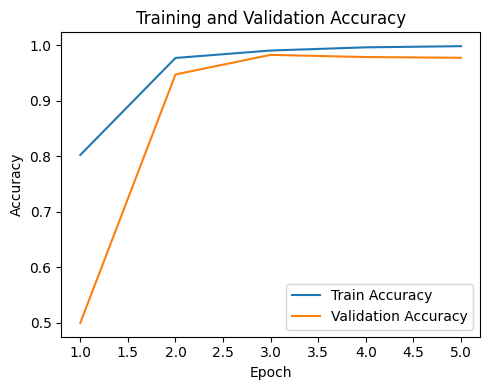

In [ ]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_acc) + 1)

plt.figure(figsize=(5,4))
plt.plot(epochs, train_acc, label="Train Accuracy")
plt.plot(epochs, val_acc, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()

plt.tight_layout()
plt.savefig("Fig_Accuracy_Dataset1.png", dpi=300, bbox_inches="tight")
plt.show()


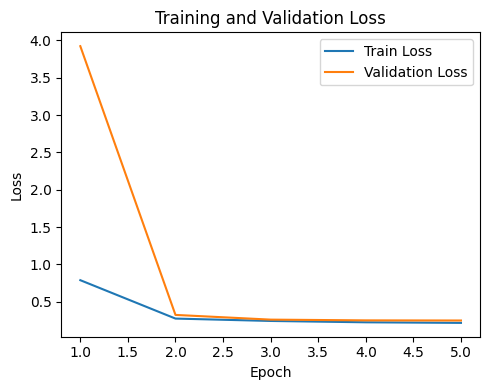

In [ ]:
plt.figure(figsize=(5,4))
plt.plot(epochs, train_loss, label="Train Loss")
plt.plot(epochs, val_loss, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()

plt.tight_layout()
plt.savefig("Fig_Loss_Dataset1.png", dpi=300, bbox_inches="tight")
plt.show()
